In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pynucastro as pyna


In [2]:
# Comparison of Heating rates between Tian and Jina
# Approach_I
Heating_Tian_Alpha_I = pd.read_csv(r'epsilon_calculations/approach_I/Run_4/Alpha.csv', skiprows=1, header=None)
Heating_Tian_Beta_I = pd.read_csv(r'epsilon_calculations/approach_I/Run_4/Beta_minus.csv', skiprows=1, header=None)
Heating_Jina_Alpha_I = pd.read_csv(r'epsilon_calculations/approach_I/Run_1/Alpha.csv', skiprows=1, header=None)
Heating_Jina_Beta_I = pd.read_csv(r'epsilon_calculations/approach_I/Run_1/Beta_minus.csv', skiprows=1, header=None)
# Approach_II
Heating_Tian_Alpha_II = pd.read_csv(r'epsilon_calculations/approach_II/Run_Tian_NMHF/Alpha.csv', skiprows=1, header=None)
Heating_Tian_Beta_II = pd.read_csv(r'epsilon_calculations/approach_II/Run_Tian_NMHF/Beta_minus.csv', skiprows=1, header=None)
Heating_Jina_Alpha_II = pd.read_csv(r'epsilon_calculations/approach_II/Run_1/Alpha.csv', skiprows=1, header=None)
Heating_Jina_Beta_II = pd.read_csv(r'epsilon_calculations/approach_II/Run_1/Beta_minus.csv', skiprows=1, header=None)


Text(0.5, 1.0, 'Heating rates comparison between Tian and Jina - Approach I')

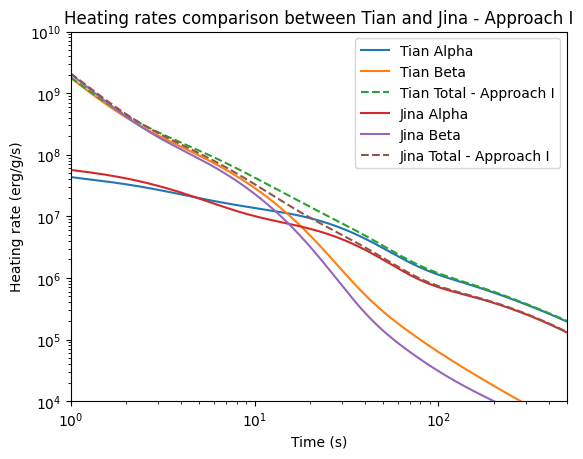

In [3]:
initial_time=1 #seconds
final_time=4.32E7 #seconds 500 days= 4.32E7 seconds 100 days= 8.64E7 seconds
N_steps=10000
time = np.exp(np.linspace(np.log(initial_time), np.log(final_time), N_steps))
time_days=time/(24*3600)
plt.Figure(figsize=(16, 12))
plt.plot(time_days, Heating_Tian_Alpha_I[1], label='Tian Alpha')
plt.plot(time_days, Heating_Tian_Beta_I[1], label='Tian Beta')
plt.plot(time_days, Heating_Tian_Alpha_I[1]+Heating_Tian_Beta_I[1], label='Tian Total - Approach I', linestyle='--')
plt.plot(time_days, Heating_Jina_Alpha_I[1], label='Jina Alpha')
plt.plot(time_days, Heating_Jina_Beta_I[1], label='Jina Beta')
plt.plot(time_days, Heating_Jina_Alpha_I[1]+Heating_Jina_Beta_I[1], label='Jina Total - Approach I', linestyle='--')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Time (s)')
plt.ylabel('Heating rate (erg/g/s)')
plt.xlim(1, 5e2)
plt.ylim(1e4, 1e10)
plt.legend()
plt.title('Heating rates comparison between Tian and Jina - Approach I')

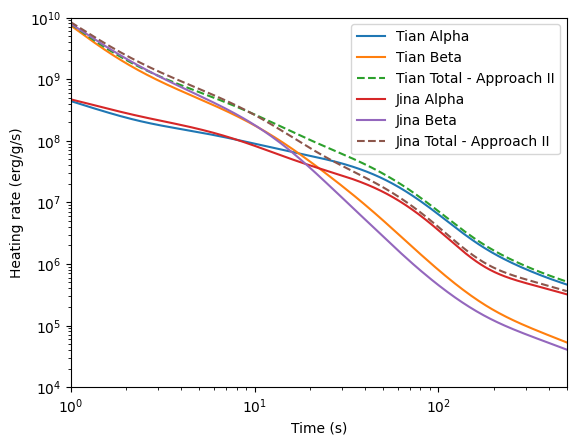

In [4]:
plt.Figure(figsize=(16,12))
plt.plot(time_days, Heating_Tian_Alpha_II[1], label='Tian Alpha')
plt.plot(time_days, Heating_Tian_Beta_II[1], label='Tian Beta')
plt.plot(time_days, Heating_Tian_Alpha_II[1]+Heating_Tian_Beta_II[1], label='Tian Total - Approach II', linestyle='--') 
plt.plot(time_days, Heating_Jina_Alpha_II[1], label='Jina Alpha')
plt.plot(time_days, Heating_Jina_Beta_II[1], label='Jina Beta')
plt.plot(time_days, Heating_Jina_Alpha_II[1]+Heating_Jina_Beta_II[1], label='Jina Total - Approach II', linestyle='--')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Time (s)')
plt.ylabel('Heating rate (erg/g/s)')
plt.xlim(1, 5e2)
plt.ylim(1e4, 1e10)
plt.legend()

In [7]:
#comparison of the beta decay rates between Tian and Jina

filter_alpha=pyna.RateFilter(
    products=['he4'],
    exact=False,
    max_reactants=1,
    max_products=2,
    filter_function=lambda r: r.reactants[0].Z==r.products[0].Z+r.products[1].Z and r.Q>0)

filter_beta_minus=pyna.RateFilter(
    max_reactants=1,
    max_products=1,
    filter_function=lambda r: r.reactants[0].Z==r.products[0].Z-1 and r.Q>0)

Tian_decay_rates = pyna.rates.library.ReacLibLibrary(libfile='Empirical_formulas/Beta_minus_empirical/Tian2025/Tian_beta_R1').filter(filter_beta_minus)
Jina_decay_rates = pyna.rates.library.ReacLibLibrary(libfile='Nuclear_Data/Original_files/Reaclib_18_9_20').filter(filter_beta_minus)
Zhou_decay_rates = pyna.rates.library.ReacLibLibrary(libfile='Empirical_formulas/Beta_minus_empirical/Zhou2017/Zhou_beta_R1').filter(filter_beta_minus)

Tian_overlap_rates = []
Tian_overlap_rates_Zhou = []
Jina_overlap_rates = []
Zhou_overlap_rates = []
n=0

for rate in Tian_decay_rates.get_rates():
    rate_Jina = Jina_decay_rates.get_rate_by_nuclei(rate.reactants, rate.products)    
    if  rate_Jina is not None:

        if type(rate_Jina) is not list:
            Tian_overlap_rates.append(rate)
            Jina_overlap_rates.append(rate_Jina)

        else:
            n+=1
    rate_Zhou = Zhou_decay_rates.get_rate_by_nuclei(rate.reactants, rate.products)
    if  rate_Zhou is not None:

        if type(rate_Zhou) is not list:

            Zhou_overlap_rates.append(rate_Zhou)
            Tian_overlap_rates_Zhou.append(rate)

print(f'Number of rates in Tian that are not in Jina: {len(Tian_overlap_rates)}')

Number of rates in Tian that are not in Jina: 4610


(1e-20, 100000.0)

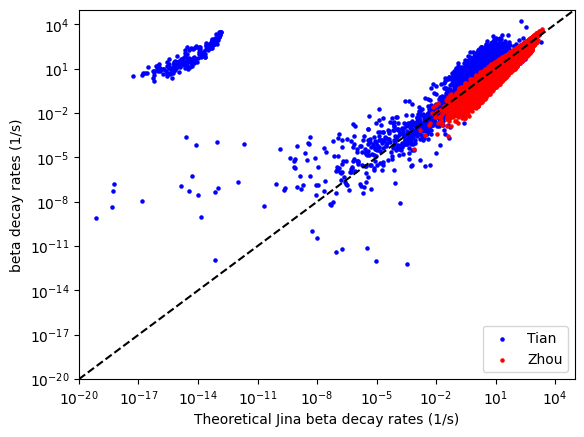

In [12]:
plt.Figure(figsize=(16,12))
plt.scatter([rate.eval(1e9) for rate in Jina_overlap_rates], [rate.eval(1e9) for rate in Tian_overlap_rates], label='Tian', color='blue', s=5)
plt.scatter([rate.eval(1e9) for rate in Zhou_overlap_rates], [rate.eval(1e9) for rate in Tian_overlap_rates_Zhou], label='Zhou', color='red', s=5)
plt.plot([1e-20, 1e5], [1e-20, 1e5], color='black', linestyle='--')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Theoretical Jina beta decay rates (1/s)')
plt.ylabel('beta decay rates (1/s)')
plt.legend()
plt.xlim(1e-20, 1e5)
plt.ylim(1e-20, 1e5)